In [1]:
import pandas as pd
def project_fcf(a):
    years = list(range(1, len(a["revenue_growth_rates"]) + 1))
    revenues = []
    revenue = a["revenue_base"]
    for g in a["revenue_growth_rates"]:
        revenue = revenue * (1 + g)
        revenues.append(revenue)

    df = pd.DataFrame({"Year": years, "Revenue": revenues})
    df["EBIT"] = df["Revenue"] * a["ebit_margin"]
    df["NOPAT"] = df["EBIT"] * (1 - a["tax_rate"])
    df["D&A"] = df["Revenue"] * a["depreciation_pct_revenue"]
    df["Capex"] = df["Revenue"] * a["capex_pct_revenue"]
    df["Change_in_WC"] = df["Revenue"] * a["change_in_wc_pct_revenue"]
    df["FCFF"] = df["NOPAT"] + df["D&A"] - df["Capex"] - df["Change_in_WC"]
    return df.set_index("Year")

In [2]:
assumptions = {
    "company_name" : "Britannia Industries ",
    "revenue_base"  : 19152 ,
    "ebit_margin"  : 0.18 ,
    "tax_rate"     : 0.23 ,
    "revenue_growth_rates" : [0.07,0.065,0.06,0.055,0.05] ,
    "depreciation_pct_revenue" : 337/19152,
    "capex_pct_revenue": 206/19152,
    "change_in_wc_pct_revenue" : 822/19152,
    "beta" : 0.42,
    "risk_free_rate" : 0.069 ,
    "market_risk_premium" : 0.06,
    "terminal_growth_rate" : 0.05,
    "cost_of_debt" : 113/1380 ,
    "debt" : 1380 ,
    "total_debt" : 1380 ,
    "equity_market_value" : 127865 ,
    "cash_and_investment" : 3962 ,
    "shares_outstanding" : 127865/5308 ,
    "current_market_price" : 5308 ,
        }
    

In [3]:
fcf_df = project_fcf(assumptions)
fcf_df

,Revenue,EBIT,NOPAT,D&A,Capex,Change_in_WC,FCFF
Year,,,,,,,
1,20492.640000,3688.675200,2840.279904,360.590000,220.420000,879.540000,2100.909904
2,21824.661600,3928.439088,3024.898098,384.028350,234.747300,936.710100,2237.469048
3,23134.141296,4164.145433,3206.391984,407.070051,248.832138,992.912706,2371.717191
4,24406.519067,4393.173432,3382.743543,429.458904,262.517906,1047.522905,2502.161636
5,25626.845021,4612.832104,3551.880720,450.931849,275.643801,1099.899050,2627.269718


In [4]:
def calculate_wacc(a):
    cost_of_equity = a["risk_free_rate"] + a["beta"] * a["market_risk_premium"]
    E = a["equity_market_value"]
    D = a["debt"]
    V = E + D
    wacc = (E/V)* cost_of_equity + (D/V) * a["cost_of_debt"]* (1-a["tax_rate"])
    return wacc ,cost_of_equity


In [5]:
wacc, cost_of_equity = calculate_wacc(assumptions)
print(f"Cost of Equity: {cost_of_equity:.2%}")
print(f"WACC:           {wacc:.2%}")

Cost of Equity: 9.42%
WACC:           9.39%


In [6]:
def discount_cash_flows(fcf_df ,wacc , terminal_growth):
    discount_factors =[(1/(1+wacc)** yr) for yr in fcf_df.index]
    pv_fcf = fcf_df["FCFF"].values * discount_factors
    pv_of_fcf_sum = pv_fcf.sum()

    final_year_fcf = fcf_df["FCFF"].iloc[-1]
    terminal_value = final_year_fcf *(1+ terminal_growth) / (wacc - terminal_growth)
    pv_terminal_value = terminal_value * discount_factors[-1]

    enterprise_value = pv_of_fcf_sum + pv_terminal_value
    return {
        "pv_of_fcf_sum" : pv_of_fcf_sum,
        "terminal_value" : terminal_value,
        "pv_terminal_value" : pv_terminal_value,
        "enterprise_value" : enterprise_value,
    }
    

In [7]:
dcf_result = discount_cash_flows(fcf_df, wacc , assumptions["terminal_growth_rate"])
for k, v in dcf_result.items():
    print(f"{k:20s}:{v:,.1f}")

pv_of_fcf_sum       :9,027.8
terminal_value      :62,885.7
pv_terminal_value   :40,154.0
enterprise_value    :49,181.8


In [8]:
def ev_to_share_price(enterprise_value, a) :
    equity_value = enterprise_value - a["total_debt"] + a["cash_and_investment"]
    implied_price = equity_value/a["shares_outstanding"]
    upside_pct = (implied_price/a["current_market_price"]) -1
    return {
        "equity_value" : equity_value,
        "implied_share_price" : implied_price ,
        "upside_downside_pct" : upside_pct ,
    }
    

In [9]:
valuation = ev_to_share_price(dcf_result["enterprise_value"] , assumptions)
print(f"Equity Value :          {valuation['equity_value']:,.1f}")
print(f"Implied Share Price :   {valuation['implied_share_price']:,.1f}")
print(f"Current Market Price :  {assumptions['current_market_price']:,.2f}")
print(f"Upside / (Downside) :   {valuation ['upside_downside_pct']:,.1%}")



Equity Value :          51,763.8
Implied Share Price :   2,148.8
Current Market Price :  5,308.00
Upside / (Downside) :   -59.5%


In [10]:
import numpy as np

In [13]:
def sensitivity_table(a, wacc_range, tg_range):
    fcf = project_fcf(a)
    rows = []

    for w in wacc_range:
        for t in tg_range:
            if w <= t:
                continue
            dcf_res = discount_cash_flows(fcf, w, t)
            val = ev_to_share_price(dcf_res["enterprise_value"], a)
            rows.append({
                "WACC": f"{w:.1%}",
                "Terminal Growth": f"{t:.1%}",
                "Price": round(val["implied_share_price"], 1)
            })

    results_df = pd.DataFrame(rows)
    table = results_df.pivot(index="WACC", columns="Terminal Growth", values="Price")
    return table

In [14]:
wacc_range = np.arange(wacc-0.02,wacc+0.025,0.01)
tg_range = np.arange(0.03,0.065,0.01)

sens_table = sensitivity_table(assumptions,wacc_range,tg_range)
sens_table

Terminal Growth,3.0%,4.0%,5.0%,6.0%
WACC,,,,
10.4%,1400.0,1555.7,1769.2,2080.0
11.4%,1243.9,1358.2,1508.4,1714.4
7.4%,2296.1,2848.1,3862.7,6340.6
8.4%,1886.4,2220.8,2752.7,3730.4
9.4%,1605.1,1826.5,2148.8,2661.6


In [15]:
import matplotlib.pyplot as plt

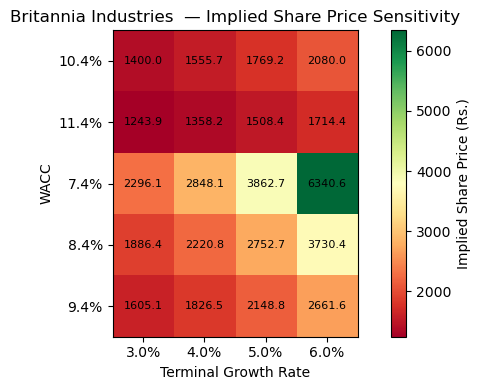

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
data = sens_table.astype(float)
im = ax.imshow(data.values, cmap="RdYlGn")
ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns)
ax.set_yticks(range(len(data.index))); ax.set_yticklabels(data.index)
ax.set_xlabel("Terminal Growth Rate")
ax.set_ylabel("WACC")
ax.set_title(f"{assumptions['company_name']} — Implied Share Price Sensitivity")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, data.values[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Implied Share Price (Rs.)")
plt.tight_layout()
plt.savefig("britannia_sensitivity_heatmap.png", dpi=150)
plt.show()

In [17]:
output_file = f"{assumptions['company_name'].replace(' ', '_')}_DCF_Valuation.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    assumptions_display = {k: (v if not isinstance(v, list) else str(v)) for k, v in assumptions.items()}
    assumptions_df = pd.DataFrame(list(assumptions_display.items()), columns=["Assumption", "Value"])
    assumptions_df.to_excel(writer, sheet_name="Assumptions", index=False)

    fcf_df.round(1).to_excel(writer, sheet_name="FCF Projection")

    summary_df = pd.DataFrame({
        "Metric": ["WACC", "Cost of Equity", "Enterprise Value", "Equity Value",
                   "Implied Share Price", "Current Market Price", "Upside / (Downside)"],
        "Value": [f"{wacc:.2%}", f"{cost_of_equity:.2%}",
                  f"{dcf_result['enterprise_value']:,.1f}", f"{valuation['equity_value']:,.1f}",
                  f"{valuation['implied_share_price']:,.2f}", f"{assumptions['current_market_price']:,.2f}",
                  f"{valuation['upside_downside_pct']:.1%}"]
    })
    summary_df.to_excel(writer, sheet_name="Valuation Summary", index=False)

    sens_table.to_excel(writer, sheet_name="Sensitivity Table")

    for sheet_name in writer.sheets:
        ws = writer.sheets[sheet_name]
        for col in ws.columns:
            max_len = max(len(str(cell.value)) if cell.value is not None else 0 for cell in col)
            ws.column_dimensions[col[0].column_letter].width = max_len + 3

print(f"Excel file created: {output_file}")

Excel file created: Britannia_Industries__DCF_Valuation.xlsx
